In [1]:
%pip install seaborn

Note: you may need to restart the kernel to use updated packages.


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (8, 4.5)

df = pd.read_csv('ames_housing.csv')
print(f"loaded ames housing: {df.shape[0]} houses, {df.shape[1]} columns")

loaded ames housing: 1460 houses, 11 columns


Part A — run the first-30-minutes checklist

TASK 01 

Understand the data before any charts

The curriculum's EDA checklist. Never skip this on a new dataset.

In [3]:
# print shape and a peek
print("shape :", df.shape)
df.head()

shape : (1460, 11)


,Id,Neighborhood,OverallQual,GrLivArea,YearBuilt,Bedrooms,FullBath,GarageCars,LotArea,SalePrice,LotFrontage
0,1,BrkSide,4,1726,1963,4,1,2,9055,188300,64.0
1,2,CollgCr,6,2292,1921,5,2,2,12134,267200,42.0
2,3,BrkSide,5,2063,2001,3,2,2,9699,254400,77.0
3,4,Edwards,6,2379,1952,4,1,3,16192,230600,NaN
4,5,NoRidge,8,2339,1996,4,2,2,10937,390200,74.0


In the given data there is 1460 rows and 11 columns.

In [4]:
#types and non_null counts
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 11 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Id            1460 non-null   int64  
 1   Neighborhood  1460 non-null   str    
 2   OverallQual   1460 non-null   int64  
 3   GrLivArea     1460 non-null   int64  
 4   YearBuilt     1460 non-null   int64  
 5   Bedrooms      1460 non-null   int64  
 6   FullBath      1460 non-null   int64  
 7   GarageCars    1460 non-null   int64  
 8   LotArea       1460 non-null   int64  
 9   SalePrice     1460 non-null   int64  
 10  LotFrontage   1212 non-null   float64
dtypes: float64(1), int64(9), str(1)
memory usage: 125.6 KB


In [5]:
# Numeric Summary
df.describe()

,Id,OverallQual,GrLivArea,YearBuilt,Bedrooms,FullBath,GarageCars,LotArea,SalePrice,LotFrontage
count,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1212.000000
mean,730.500000,5.332877,1870.500000,1961.327397,3.600685,2.052740,1.881507,12712.554110,237645.342466,70.020627
std,421.610009,1.711194,462.482643,31.217510,0.945463,0.718377,0.803736,4514.118369,65093.454820,21.901410
min,1.000000,1.000000,656.000000,1900.000000,1.000000,1.000000,0.000000,1500.000000,92100.000000,21.000000
25%,365.750000,4.000000,1559.000000,1935.000000,3.000000,2.000000,1.000000,10292.500000,187550.000000,55.000000
50%,730.500000,5.000000,1846.000000,1961.000000,4.000000,2.000000,2.000000,12694.500000,230600.000000,69.000000
75%,1095.250000,6.000000,2163.250000,1988.000000,4.000000,3.000000,2.000000,15152.500000,276750.000000,85.000000
max,1460.000000,10.000000,4600.000000,2010.000000,6.000000,4.000000,4.000000,115000.000000,595000.000000,138.000000


In [6]:
# Category-neighbourhood
print('neighbourhood and their counts:')
print(df['Neighborhood'].value_counts())

neighbourhood and their counts:
Neighborhood
OldTown    182
CollgCr    166
BrkSide    148
Edwards    146
Gilbert    140
NWAmes     125
Somerst    117
BrDale      77
IDOTRR      67
Timber      61
MeadowV     60
NridgHt     51
NoRidge     49
StoneBr     44
Veenker     27
Name: count, dtype: int64


In [7]:
# For missing value
print("missing values per column:")
print(df.isnull().sum()[df.isnull().sum() > 0])
print(f"missing fraction: {df['LotFrontage'].isnull().mean():.0%}")

missing values per column:
LotFrontage    248
dtype: int64
missing fraction: 17%


LotFront is missing for 248 of 1460 houses (17%)

Suspicious values: LotArea has a very high maximum of 115,000 compared with its 75th percentile of 15,152.5, indicating a possible extreme outlier. GrLivArea also has some unusually large values, with a maximum of 4,600 compared with a 75th percentile of 2,163. SalePrice has a mean of 237,645 versus a median of 230,600, suggesting slight right-skew from higher-priced houses. No clearly impossible minimum values are present. LotFrontage contains 248 missing values, approximately 17% of the dataset.

Rough range: SalePrice ranges from approximately 92,100 dollar to $595,000.

Typical value: The typical house sells for around 230,600 dollar (median), with an average of about $237,645.

Part B — 10+ visualizations telling a story (the deliverable)

TASK 02 

Univariate — each variable's own shape

The curriculum's univariate analysis. At least 3 charts here.

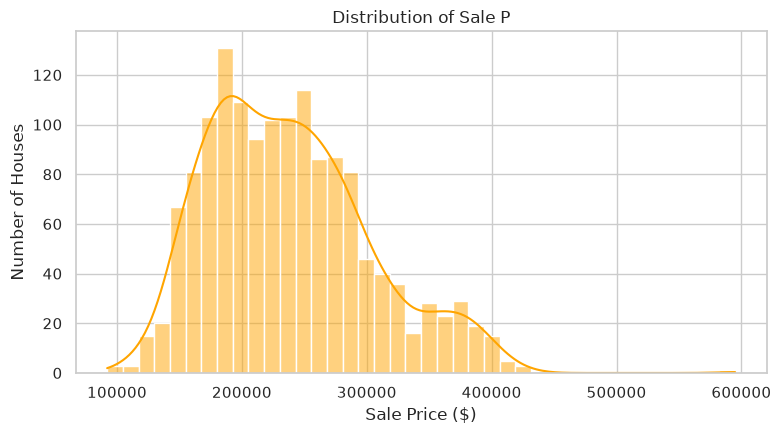

In [8]:
# distribution of SalePrice
fig, ax = plt.subplots()
sns.histplot(df['SalePrice'], bins=40, kde=True, color='orange', ax=ax)
ax.set_title("Distribution of Sale P")
ax.set_xlabel("Sale Price ($)")
ax.set_ylabel("Number of Houses")
plt.tight_layout()
plt.show()

The price distribution is right-skewed

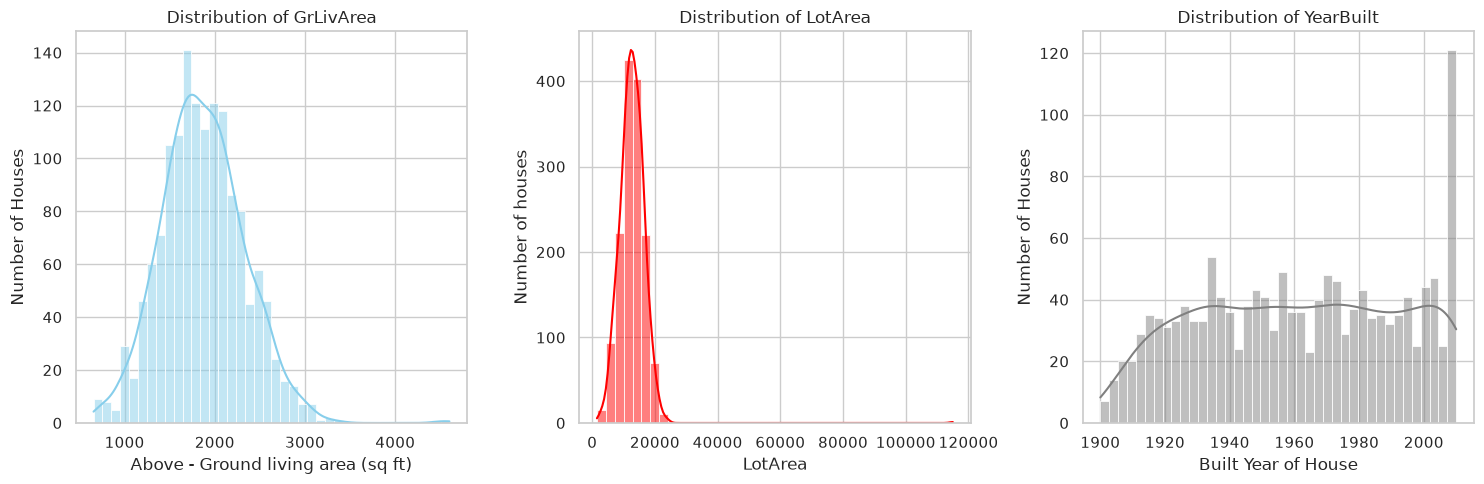

In [9]:
# Plot the distribution of at least two other numeric columns (e.g. GrLivArea, LotArea, YearBuilt).
fig, ax = plt.subplots(1, 3, figsize=(15, 5))
# Distribution of GrLivArea
sns.histplot(df['GrLivArea'], bins=40, kde=True, color="skyblue", ax=ax[0])
ax[0].set_title("Distribution of GrLivArea")
ax[0].set_xlabel("Above - Ground living area (sq ft)")
ax[0].set_ylabel("Number of Houses")

# Distribution of LotArea
sns.histplot(df['LotArea'], bins=40, kde=True, color='red', ax=ax[1])
ax[1].set_title("Distribution of LotArea")
ax[1].set_xlabel("LotArea")
ax[1].set_ylabel("Number of houses")

# Distribution of YearBuilt
sns.histplot(df['YearBuilt'], bins=40, kde=True, color='gray', ax=ax[2])
ax[2].set_title("Distribution of YearBuilt")
ax[2].set_xlabel("Built Year of House")
ax[2].set_ylabel("Number of Houses")

plt.tight_layout()
plt.show()

* GrLivArea: Right-skewed, with most houses having moderate living areas and a few unusually large houses standing out as potential outliers.
* LotArea: Strongly right-skewed, with a small number of houses having extremely large lots.
* YearBuilt: Mostly concentrated in more recent construction years, with fewer houses built in the very early years.

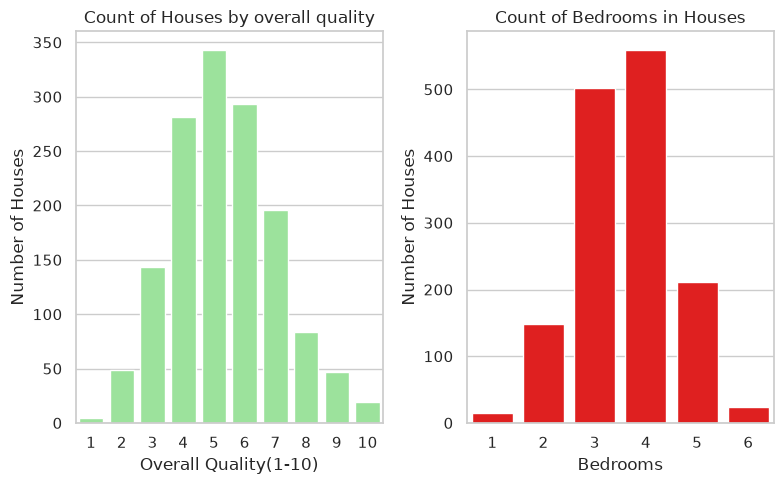

In [10]:
# Plot a count of a categorical or discrete column (OverallQual, or Bedrooms).
fig, ax = plt.subplots(1, 2, figsize=(8, 5))

# For over all quality
sns.countplot(x='OverallQual', data=df, color='lightgreen', ax=ax[0])
ax[0].set_title("Count of Houses by overall quality")
ax[0].set_xlabel("Overall Quality(1-10)")
ax[0].set_ylabel("Number of Houses")

# For bedrooms
sns.countplot(x='Bedrooms', data=df, color='red', ax=ax[1])
ax[1].set_title("Count of Bedrooms in Houses")
ax[1].set_xlabel("Bedrooms")
ax[1].set_ylabel("Number of Houses")

plt.tight_layout()
plt.show()

* OverallQual: Concentrated around the middle quality ratings, with relatively few houses at the very low or very high quality levels.
* Bedrooms: Mostly concentrated around 2–4 bedrooms, with 3 bedrooms being the most common; very high bedroom counts are rare and stand out as potential outliers.

TASK 03 

Bivariate — what drives price?

The curriculum's bivariate analysis. At least 3 charts here.

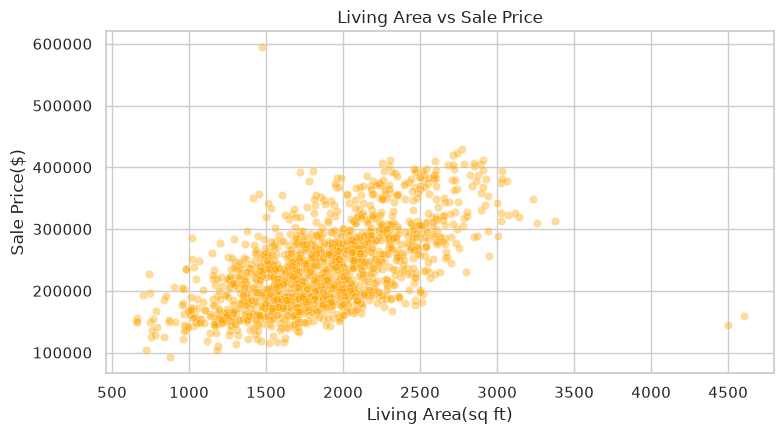

In [11]:
# Scatter plot: GrLivArea vs SalePrice.
fig, ax = plt.subplots()
sns.scatterplot(data=df, x='GrLivArea', y='SalePrice', alpha=0.4, color='orange', ax=ax)
ax.set_title("Living Area vs Sale Price")
ax.set_xlabel("Living Area(sq ft)")
ax.set_ylabel("Sale Price($)")
plt.tight_layout()
plt.show()

* One-line description: GrLivArea and SalePrice show a positive relationship—larger living areas generally correspond to higher sale prices.
* Points that break the pattern: Yes, there are two outliers, especially houses with very large GrLivArea but unusually low SalePrice.

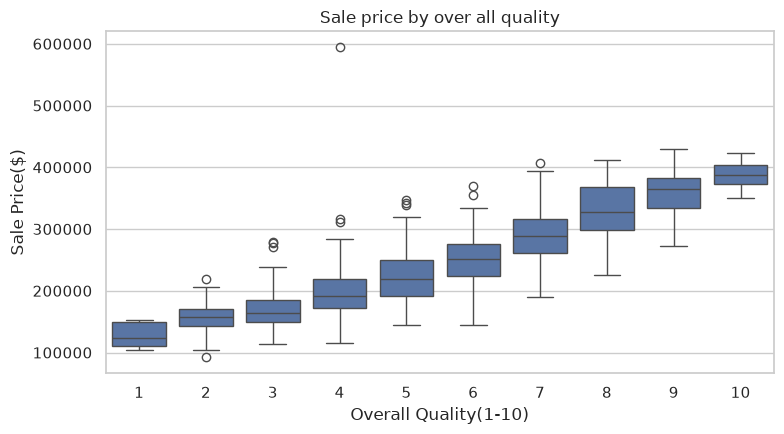

In [12]:
# Boxplot: SalePrice across OverallQual levels.
fig, ax = plt.subplots()
sns.boxplot(x='OverallQual', y='SalePrice', data=df, ax=ax)
ax.set_title("Sale price by over all quality")
ax.set_xlabel("Overall Quality(1-10)")
ax.set_ylabel("Sale Price($)")
plt.tight_layout()
plt.show()

* Takeaway: Yes, price generally climbs strongly with OverallQual; higher-quality houses have noticeably higher median prices, though there is some variation and overlap between levels.

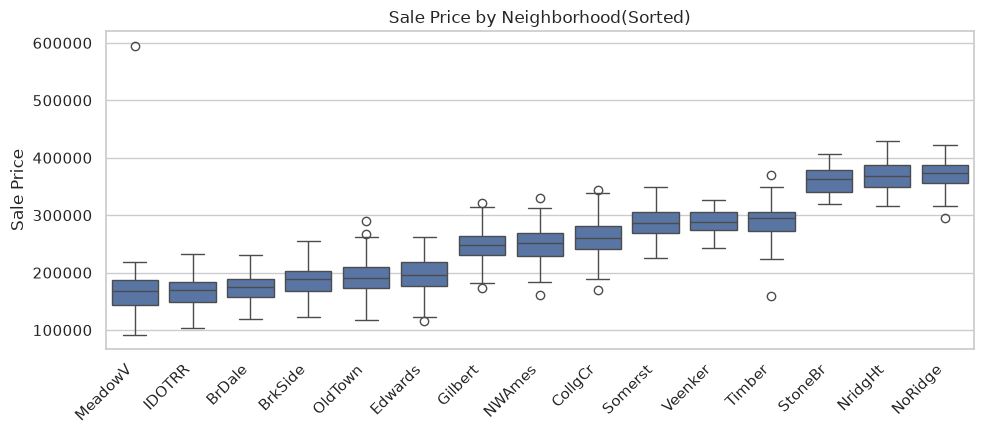

In [13]:
# Boxplot: SalePrice by Neighborhood — and sort the neighborhoods by median price.
order = df.groupby('Neighborhood')['SalePrice'].median().sort_values().index
fig, ax = plt.subplots(figsize=(10, 4.5))
sns.boxplot(x='Neighborhood', y='SalePrice', data=df, order=order, ax=ax)
ax.set_title("Sale Price by Neighborhood(Sorted)")
ax.set_xlabel("")
ax.set_ylabel("Sale Price")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

* Takeaway: There is a strong relationship between neighborhood and SalePrice; median prices vary considerably across neighborhoods, creating a clear low-to-high ranking.

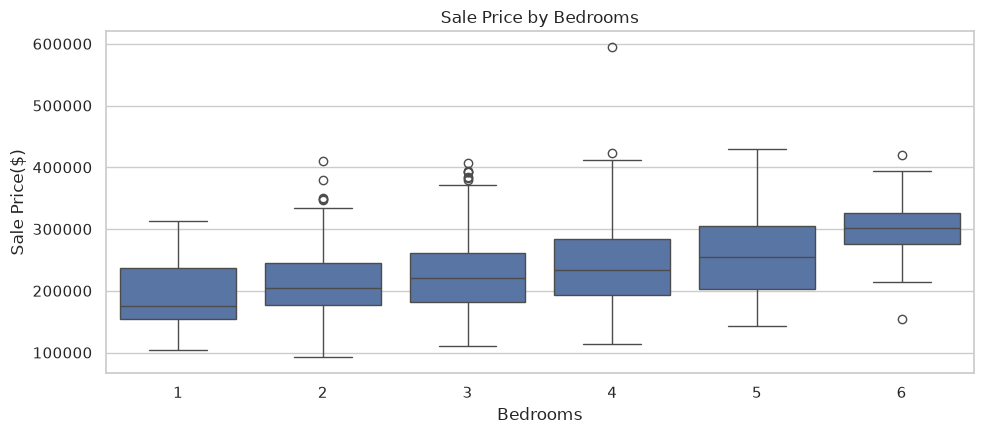

In [14]:
# Boxplot: SalePrice by Bedrooms — and sort the Bedrooms by median price.
order = df.groupby("Bedrooms")['SalePrice'].median().sort_values().index
fig, ax = plt.subplots(figsize=(10, 4.5))
sns.boxplot(x='Bedrooms', y='SalePrice', data=df, order=order, ax=ax)
ax.set_title("Sale Price by Bedrooms")
ax.set_xlabel('Bedrooms')
ax.set_ylabel("Sale Price($)")
plt.tight_layout()
plt.show()

* Takeaway: SalePrice generally increases with the number of bedrooms, but the relationship is moderate rather than strong, with considerable variation and some overlap in prices between bedroom groups.
* More bedrooms generally correspond to higher sale prices, but the relationship is moderate and has substantial variation.

TASK 04 

Multivariate — the whole picture

The curriculum's multivariate analysis. At least 2 charts, one interactive.

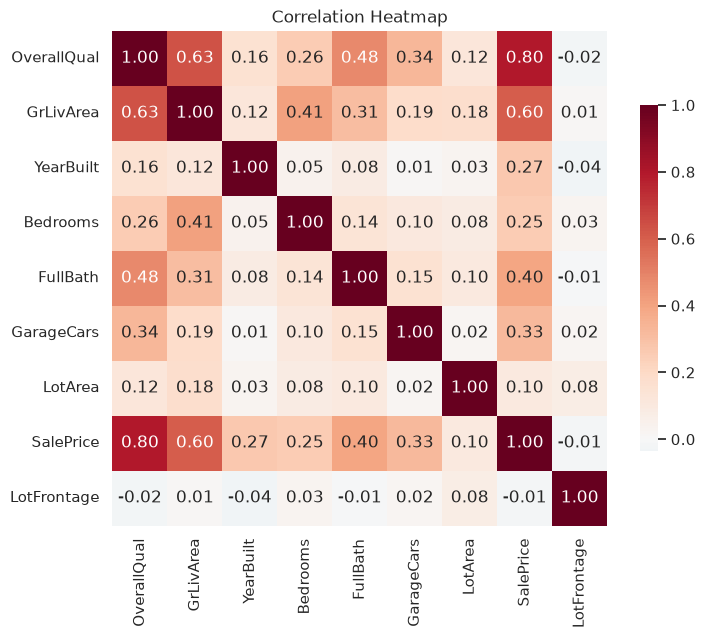

In [15]:
# Build a correlation heatmap of all numeric columns.
corr = df.select_dtypes('number').drop(columns=['Id']).corr()

fig, ax = plt.subplots(figsize=(8, 6.5))
sns.heatmap(corr, annot=True, fmt='.2f', cmap="RdBu_r", center=0,
            square=True, cbar_kws={'shrink':0.7}, ax=ax)
ax.set_title("Correlation Heatmap")
plt.tight_layout()
plt.show()

* Top 3 drivers of SalePrice: OverallQual, GrLivArea, and GarageCars, in that order, based on their correlation with SalePrice.

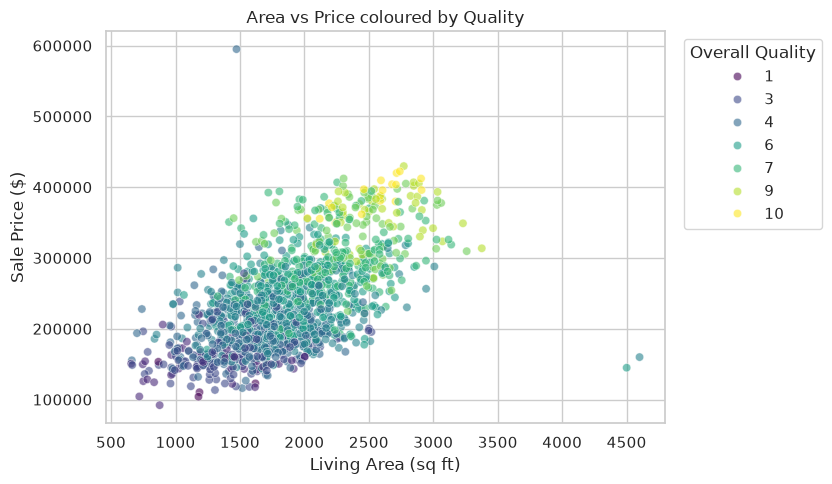

In [16]:
# Make a scatter plot that encodes a THIRD variable as colour
fig, ax = plt.subplots(figsize=(8.5, 5))
scatter = sns.scatterplot(data=df, x='GrLivArea', y='SalePrice', hue='OverallQual',
                         palette='viridis', alpha=0.6, ax=ax)

ax.set_title("Area vs Price coloured by Quality")
ax.set_xlabel("Living Area (sq ft)")
ax.set_ylabel("Sale Price ($)")
ax.legend(title='Overall Quality', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

In [17]:
%pip install -U plotly

Note: you may need to restart the kernel to use updated packages.


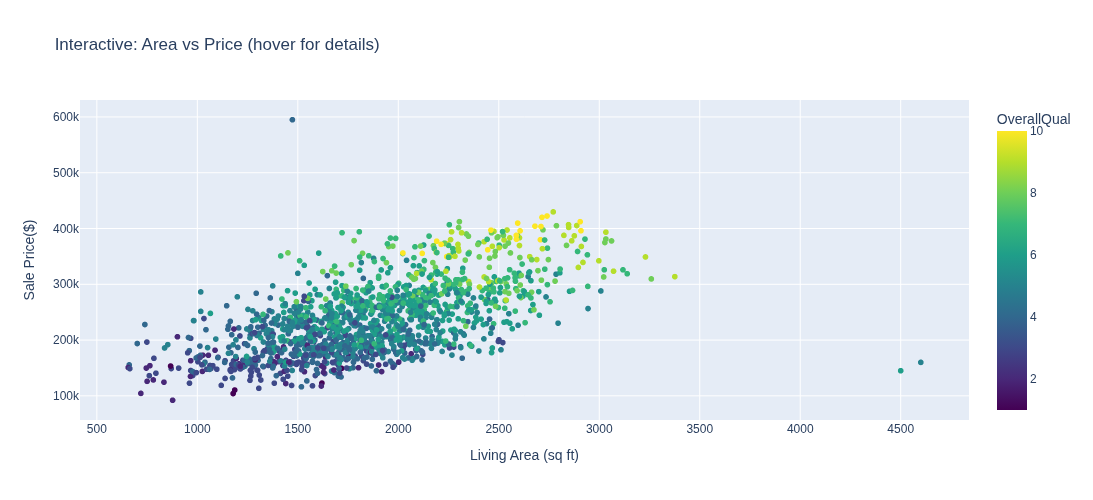

In [18]:
# Make one interactive plotly chart — a scatter you can hover, with extra details in the tooltip.
import plotly.express as px

fig = px.scatter(df, x='GrLivArea', y='SalePrice', color='OverallQual',
                hover_data = ['Neighborhood', 'YearBuilt'],
                title = 'Interactive: Area vs Price (hover for details)',
                labels = {'GrLivArea':'Living Area (sq ft)', 'SalePrice':'Sale Price($)'},
                color_continuous_scale='viridis')
fig.update_layout(width=800, height=500)
fig.show()

Part C — outliers and the wider toolkit

TASK 05 

Hunt the outliers

The curriculum's outlier detection. Find the points that don't belong.

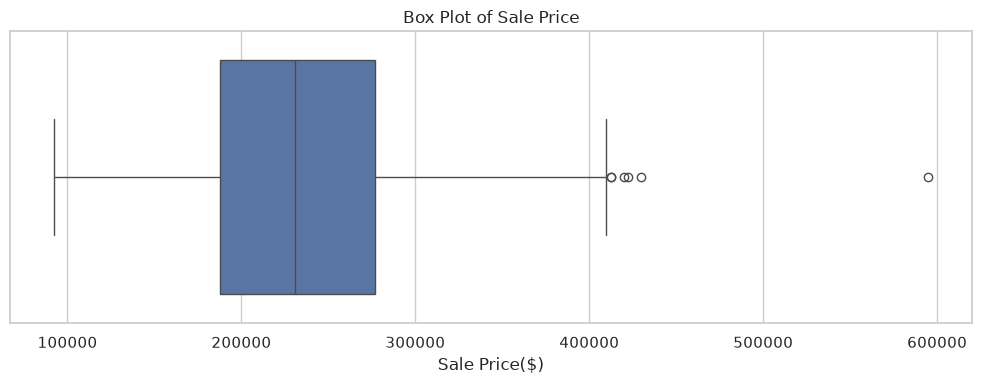

In [19]:
# boxplot of SalePrice and identify the outlier dots
fig, ax = plt.subplots(figsize=(10, 4))

sns.boxplot(x=df['SalePrice'], ax=ax)
ax.set_title("Box Plot of Sale Price")
ax.set_xlabel("Sale Price($)")
plt.tight_layout()
plt.show()

In [20]:
# IQR price outliers
q1, q3 = df['SalePrice'].quantile([0.25, 0.75])
iqr = q3 - q1

lower_bound = q1 - 1.5 * iqr
higher_bound = q3 + 1.5 * iqr

outliers = [
    (df['SalePrice'] < lower_bound) |
    (df['SalePrice'] > higher_bound)
]

print("Q1:", q1)
print("Q3:", q3)
print(f"Lower Bound (Below) : {lower_bound:,.0f}")
print(f"Higher Bound (Above) : {higher_bound:,.0f}")
print("Number of Price Outliers :", len(outliers))
print("Price Outliers:")
print(outliers)

Q1: 187550.0
Q3: 276750.0
Lower Bound (Below) : 53,750
Higher Bound (Above) : 410,550
Number of Price Outliers : 1
Price Outliers:
[0       False
1       False
2       False
3       False
4       False
        ...  
1455    False
1456    False
1457    False
1458    False
1459    False
Name: SalePrice, Length: 1460, dtype: bool]


* High SalePrice outliers: Could be genuine luxury/rare houses, so I would generally keep them unless other variables indicate an error.
* Low SalePrice outliers: Could be genuine distressed or unusual sales, so I would investigate rather than automatically delete them.

In [21]:
# Large Houses with Low prices
strange = df[(df['GrLivArea'] > 4000) & (df['SalePrice'] < 200000)]

print(f"Number of large, low-price Houses: {len(strange)}")
print(strange[['Id','GrLivArea', 'SalePrice', 'OverallQual', 'Neighborhood']].to_string(index=False))

Number of large, low-price Houses: 2
  Id  GrLivArea  SalePrice  OverallQual Neighborhood
 858       4500     145000            6       IDOTRR
1016       4600     160000            5       Timber


* Very large GrLivArea + low SalePrice: Likely suspicious observations or unusual properties rather than ordinary houses. I would investigate them first and only remove them if they are confirmed to be data-entry errors.

TASK 06 

Try plotnine (ggplot grammar)

The curriculum names plotnine — worth meeting the grammar-of-graphics style

In [22]:
%pip install plotnine

Note: you may need to restart the kernel to use updated packages.


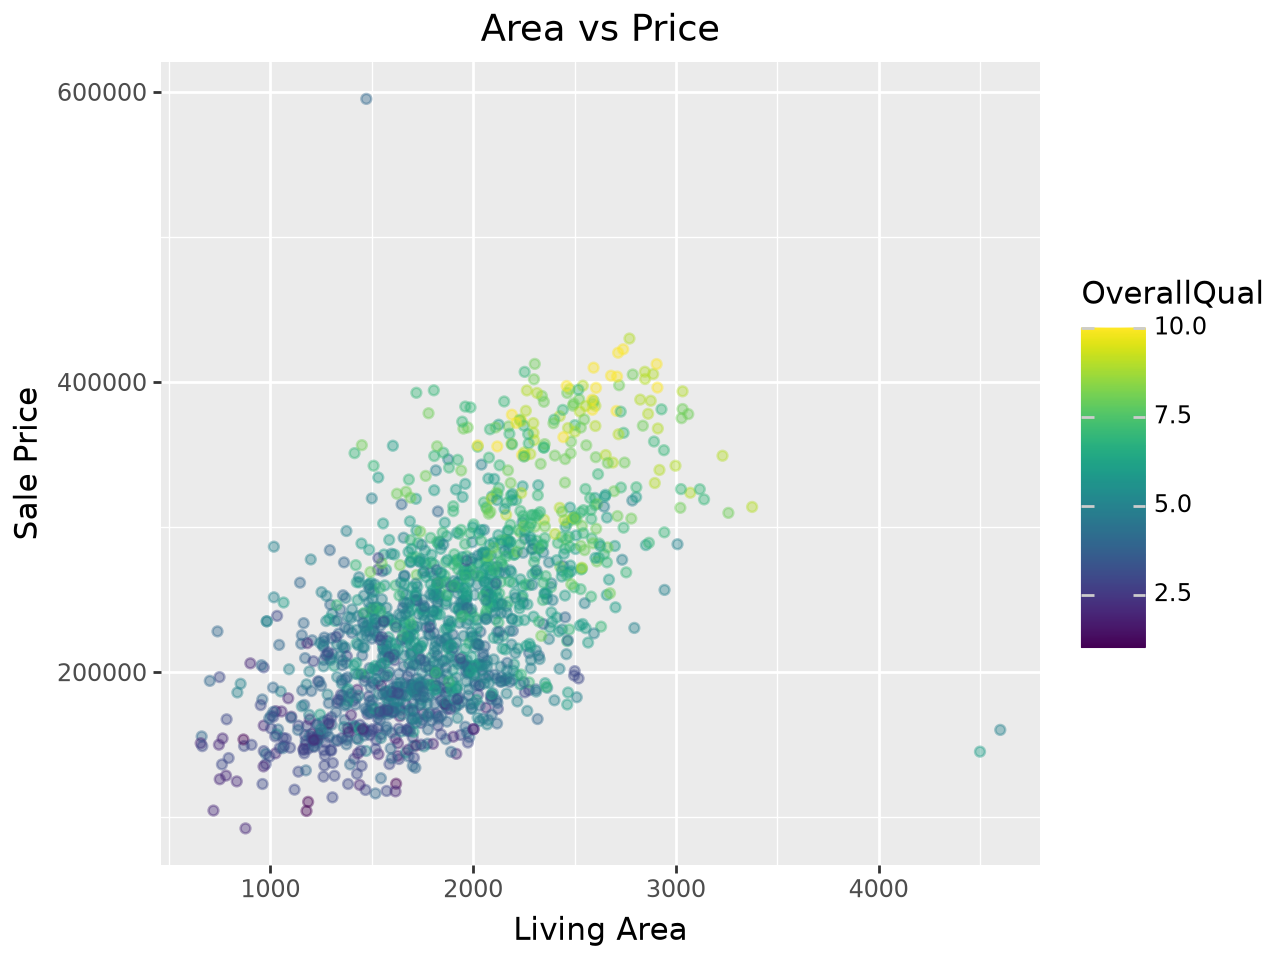

In [23]:
from plotnine import ggplot, aes, geom_point, labs
(
    ggplot(df, aes(x="GrLivArea", y='SalePrice', color='OverallQual'))
    + geom_point(alpha=0.4)
    + labs(title = "Area vs Price", x='Living Area', y='Sale Price')
)

* Plotnine feels more structured than Seaborn because the chart is built explicitly in layers: data → aesthetics → geometry → labels.
* I find Seaborn more natural for quick plots because it requires less code, while Plotnine is useful when I want a clear, systematic way to build complex charts.